# 00 LSTM Models Using 99/1 Train/Test Split
We saw in the first notebook using LSTM architecture that our test accuracies were really poor compared to our training or validation accuracies. In this second notebook, we split our data into a 99/1 train test split, as we'll have more training and validation data that's closer in time to our test data, which should theoretically make our predictions more accurate. This also has the added benefit of giving us more training data to work with in general.

**Caveat:** Please see the explanation at the bottom as to why these models ultimately needed to be reran. TLDR: our price features were all normalized to the Open of the current day (which was normalized to 1.0). This made it seem like the Open price for every day was unchanging (constantly 1.0), which made our data lose all sense of long-term price movements.

## Imports

In [596]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import date
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import heatmap

import tulipy as ti

import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import KernelPCA
from sklearn.decomposition import IncrementalPCA

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras import initializers
import keras_tuner as kt
from keras_tuner import HyperParameters

import warnings

# Data Loading and Initial Feature Engineering for LSTM Model

## Loading in Data

In [152]:
# Loading in stock data
data = pd.read_csv("SP500_4y_day_data.csv", index_col='Date', parse_dates=True)

In [153]:
# Converting Date_col to datetime format
data['Date_col'] = pd.to_datetime(data['Date_col'])

In [154]:
data

,Date_col,Ticker,Open,High,Low,Close,Volume,rank
Date,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0
...,...,...,...,...,...,...,...,...
2024-12-24,2024-12-24,ZTS,163.206597,164.542554,162.249499,164.203583,1023600.0,1001.0
2024-12-26,2024-12-26,ZTS,163.226540,165.290293,162.528653,165.021118,2167200.0,1002.0
2024-12-27,2024-12-27,ZTS,164.452833,166.028073,163.027150,164.103897,1800100.0,1003.0


## Feature Engineering
Outcome variables - Close price minus the Open price and variations of that

In [155]:
# Getting difference between close price and open price (outcome variables)
data["Close_Open_Diff"] = data["Close"] - data["Open"]
data["Close_Open_Diff_Perc"] = (data["Close"] - data["Open"]) / data["Open"] * 100

# Getting binary classification for whether a stock ended positive (1) or negative/zero (0)
data["Close_Open_Diff_Binary"] = data["Close_Open_Diff"] > 0

# Getting ternary classification for whether a stock ended positive (2), negative (0), or not much change (1)
close_open_conditions = [
    data['Close_Open_Diff_Perc'] > 0.5,       # Close price was at least 0.5% higher than Open price
    (data['Close_Open_Diff_Perc'] >= -0.5) &  # Close price was between -0.5% and 0.5% of Open price
        (data['Close_Open_Diff_Perc'] <= 0.5),
    data['Close_Open_Diff_Perc'] < -0.5       # Close price was at least 0.5% lower than Open price
]
close_open_choices = [2, 1, 0]  # Defining choices corresponding to conditions
data['Close_Open_Diff_Ternary'] = np.select(close_open_conditions, close_open_choices)  # Applying conditions

data

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,Close_Open_Diff_Binary,Close_Open_Diff_Ternary
Date,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,False,1
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,True,2
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,True,2
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,True,2
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,2024-12-24,ZTS,163.206597,164.542554,162.249499,164.203583,1023600.0,1001.0,0.996986,0.610874,True,2
2024-12-26,2024-12-26,ZTS,163.226540,165.290293,162.528653,165.021118,2167200.0,1002.0,1.794578,1.099440,True,2
2024-12-27,2024-12-27,ZTS,164.452833,166.028073,163.027150,164.103897,1800100.0,1003.0,-0.348936,-0.212180,False,1


Getting previous day metrics (since we don't know current day's metrics except open) and growth rates

In [156]:
# Getting the first actual trading day
first_trading_date = str(data.Date_col.idxmin().date())

# Getting growth rates and previous day OHLCV metrics
for x in data.columns[2:-6]:
  data[f'Growth Rate_{x}'] = (data[x] - data[x].shift(1))/data[x].shift(1) * 100
data["PDO"] = data["Open"].shift(1)
data["PDH"] = data["High"].shift(1)
data["PDL"] = data["Low"].shift(1)
data["PDC"] = data["Close"].shift(1)
data["PDV"] = data["Volume"].shift(1)

# For row in data, if date is first trading date, set above column values to null. Note: date is the index:
data.loc[first_trading_date, ['PDO', 'PDH', 'PDL', 'PDC', 'PDV', 'Growth Rate_Open', 'Growth Rate_High', 'Growth Rate_Low',
    'Growth Rate_Close']] = np.nan

data.head()

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,Close_Open_Diff_Ternary,Growth Rate_Open,Growth Rate_High,Growth Rate_Low,Growth Rate_Close,PDO,PDH,PDL,PDC,PDV
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,...,2,-0.386760,0.191515,0.819730,0.817589,115.875028,116.995388,114.092184,115.582756,2030700.0
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,2,0.177242,2.958772,0.118571,2.742242,115.426870,117.219451,115.027432,116.527748,2344000.0
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,2,4.751879,2.906048,4.991124,2.660925,115.631454,120.687707,115.163820,119.723221,2428500.0
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,...,1,1.737320,0.125518,1.401992,0.713386,121.126122,124.194950,120.911790,122.908966,1775900.0


Getting gap (i.e., change from some previous day metric) features and volume features

In [157]:
# Getting the opening gap features from PDC
data["Gap_from_PDC"] = (data["Open"] - data["PDC"]) / data["PDC"]
gap_from_PDC_threshold = 0.02  # 2%
data["Gap_Binary_Threshold"] = abs(data["Gap_from_PDC"]) > gap_from_PDC_threshold

# Getting daily range gap up features
data["Daily_Range_Gap_Up"] = (data["Open"] - data["PDH"]) / data["PDH"]
data["Daily_Range_Gap_Up"] = data["Daily_Range_Gap_Up"].clip(lower = 0)
data["DR_Gap_Up_Binary"] = data["Daily_Range_Gap_Up"] > 0

# Getting daily range gap down features
data["Daily_Range_Gap_Down"] = (data["Open"] - data["PDL"]) / data["PDL"]
data["Daily_Range_Gap_Down"] = data["Daily_Range_Gap_Down"].clip(upper = 0)
data["DR_Gap_Down_Binary"] = data["Daily_Range_Gap_Down"] < 0

# Getting 14-day average volume and previous volume features
avg_vol_window = 14
data["Avg_Volume_14D"] = data["Volume"].rolling(window=avg_vol_window).mean()
data["Avg_Vol_Prev_14D"] = data["PDV"].rolling(window=avg_vol_window).mean()

# Comparing current volume to average volume over the past XX days
data["Vol_Change"] = (data["Volume"] - data["Avg_Vol_Prev_14D"]) / data["Avg_Vol_Prev_14D"]

# Setting the first 14-day volume averages and previous averages of every ticker to np.nan
data.loc[data["rank"] < 15, ["Avg_Volume_14D", "Avg_Vol_Prev_14D", "Vol_Change"]] = np.nan

data[10:20]

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,PDV,Gap_from_PDC,Gap_Binary_Threshold,Daily_Range_Gap_Up,DR_Gap_Up_Binary,Daily_Range_Gap_Down,DR_Gap_Down_Binary,Avg_Volume_14D,Avg_Vol_Prev_14D,Vol_Change
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-19,2021-01-19,A,124.097539,124.506722,123.035631,124.068314,1677200.0,11.0,-0.029226,-0.023551,...,2115400.0,0.009270,False,0.002045,True,0.000000,False,NaN,NaN,NaN
2021-01-20,2021-01-20,A,124.419037,125.597856,124.078058,124.808731,1843000.0,12.0,0.389694,0.313211,...,1677200.0,0.002827,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-21,2021-01-21,A,124.477480,125.461455,123.162270,123.727325,1612100.0,13.0,-0.750155,-0.602643,...,1843000.0,-0.002654,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-22,2021-01-22,A,123.805281,124.506729,123.045382,123.074608,1438700.0,14.0,-0.730673,-0.590179,...,1612100.0,0.000630,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-25,2021-01-25,A,123.425324,124.194968,121.223560,122.246506,1365400.0,15.0,-1.178819,-0.955086,...,1438700.0,0.002850,False,0.000000,False,0.000000,False,1.728993e+06,1.776514e+06,-0.231416
2021-01-26,2021-01-26,A,122.265994,122.704395,120.678000,120.726707,1476600.0,16.0,-1.539287,-1.258966,...,1365400.0,0.000159,False,0.000000,False,0.000000,False,1.667036e+06,1.728993e+06,-0.145977
2021-01-27,2021-01-27,A,118.934108,119.830399,115.066411,115.738632,1923500.0,17.0,-3.195476,-2.686762,...,1476600.0,-0.014848,False,0.000000,False,-0.014451,True,1.630964e+06,1.667036e+06,0.153845
2021-01-28,2021-01-28,A,115.933484,119.508910,115.719152,118.427513,1677900.0,18.0,2.494029,2.151258,...,1923500.0,0.001684,False,0.000000,False,0.000000,False,1.623964e+06,1.630964e+06,0.028778
2021-01-29,2021-01-29,A,118.086527,118.554161,116.206261,117.073326,1822000.0,19.0,-1.013201,-0.858016,...,1677900.0,-0.002879,False,0.000000,False,0.000000,False,1.641450e+06,1.623964e+06,0.121946


Getting technical and momentum indicators

In [158]:
# SMA and EMA including this period
data["SMA_14"] = data["Close"].rolling(window=14).mean()
data["SMA_50"] = data["Close"].rolling(window=50).mean()
data["SMA_200"] = data["Close"].rolling(window=200).mean()
data["EMA_9"] = data["Close"].ewm(span=9, adjust=False).mean()
data["EMA_20"] = data["Close"].ewm(span=20, adjust=False).mean()

# SMA and EMA for the past XXX periods
data["SMA_prev_14"] = data["PDC"].rolling(window=14).mean()
data["SMA_prev_50"] = data["PDC"].rolling(window=50).mean()
data["SMA_prev_200"] = data["PDC"].rolling(window=200).mean()
data["EMA_prev_9"] = data["PDC"].ewm(span=9, adjust=False).mean()
data["EMA_prev_20"] = data["PDC"].ewm(span=20, adjust=False).mean()

# RSI Calculation
delta = data["Close"].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
data["RSI_14"] = 100 - (100 / (1 + rs))

# RSI for the previous XX periods using tulipy
rsi_prev_14 = ti.rsi(data["PDC"].to_numpy(), 14)
nan_array_rsi = np.full(14, np.nan)
rsi_prev_14 = np.concatenate((nan_array_rsi, rsi_prev_14))
data["RSI_prev_14"] = rsi_prev_14

# ATR Calculation
data["ATR_14"] = (data["PDH"] - data["PDL"]).rolling(window=14).mean()
data["NATR_14"] = (data["ATR_14"] / data["PDC"]) * 100

# Setting 9, 14, 20, 50, and 200 day metrics to np.nan:
data.loc[data["rank"] <= 9, ['EMA_9', 'EMA_prev_9']] = np.nan
data.loc[data["rank"] <= 14, ['SMA_14', 'SMA_prev_14', 'RSI_14', 'RSI_prev_14', 'ATR_14', 'NATR_14']] = np.nan
data.loc[data["rank"] <= 20, ['EMA_20', 'EMA_prev_20']] = np.nan
data.loc[data["rank"] <= 50, ['SMA_50', 'SMA_prev_50']] = np.nan
data.loc[data["rank"] <= 200, ['SMA_200', 'SMA_prev_200']] = np.nan

data[:18]

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,EMA_20,SMA_prev_14,SMA_prev_50,SMA_prev_200,EMA_prev_9,EMA_prev_20,RSI_14,RSI_prev_14,ATR_14,NATR_14
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-11,2021-01-11,A,123.191505,126.007032,122.977180,124.847694,1746800.0,6.0,1.656190,1.344403,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-12,2021-01-12,A,125.023060,125.081511,122.947943,123.698105,1826400.0,7.0,-1.324955,-1.059768,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-13,2021-01-13,A,124.175467,124.750267,123.474019,123.707840,1530400.0,8.0,-0.467627,-0.376585,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-14,2021-01-14,A,123.990362,124.886660,122.577731,122.782318,924900.0,9.0,-1.208044,-0.974305,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [159]:
# Getting the sector for stocks as another feature
ticker_and_sector = sp500_tables[0][['Symbol', 'GICS Sector']]

# Getting the GICS sector into the table through a merge function
data = data.reset_index().merge(ticker_and_sector, left_on='Ticker', right_on='Symbol', how='left').set_index('Date')
data = data.drop(columns=['Symbol'])

# Replacing NaN GICS Sectors with Other
data['GICS Sector'] = data['GICS Sector'].fillna('Other')

data.head()

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,SMA_prev_14,SMA_prev_50,SMA_prev_200,EMA_prev_9,EMA_prev_20,RSI_14,RSI_prev_14,ATR_14,NATR_14,GICS Sector
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care


In [160]:
# Getting date index column:
date_index = data.index.sort_values()

# Dropping duplicates:
date_index = date_index.drop_duplicates()

date_index

DatetimeIndex(['2021-01-04', '2021-01-05', '2021-01-06', '2021-01-07',
               '2021-01-08', '2021-01-11', '2021-01-12', '2021-01-13',
               '2021-01-14', '2021-01-15',
               ...
               '2024-12-17', '2024-12-18', '2024-12-19', '2024-12-20',
               '2024-12-23', '2024-12-24', '2024-12-26', '2024-12-27',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', name='Date', length=1005, freq=None)

## Selecting Base Features

In [161]:
data.columns

Index(['Date_col', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'rank',
       'Close_Open_Diff', 'Close_Open_Diff_Perc', 'Close_Open_Diff_Binary',
       'Close_Open_Diff_Ternary', 'Growth Rate_Open', 'Growth Rate_High',
       'Growth Rate_Low', 'Growth Rate_Close', 'PDO', 'PDH', 'PDL', 'PDC',
       'PDV', 'Gap_from_PDC', 'Gap_Binary_Threshold', 'Daily_Range_Gap_Up',
       'DR_Gap_Up_Binary', 'Daily_Range_Gap_Down', 'DR_Gap_Down_Binary',
       'Avg_Volume_14D', 'Avg_Vol_Prev_14D', 'Vol_Change', 'SMA_14', 'SMA_50',
       'SMA_200', 'EMA_9', 'EMA_20', 'SMA_prev_14', 'SMA_prev_50',
       'SMA_prev_200', 'EMA_prev_9', 'EMA_prev_20', 'RSI_14', 'RSI_prev_14',
       'ATR_14', 'NATR_14', 'GICS Sector'],
      dtype='object')

In [162]:
# Getting a copy of the data to work with so we don't ruin original
data_small = data.copy()

# Removing BIIB ticker in general (since it's missing data for one of the trading days)
data_small = data_small[data_small['Ticker'] != 'BIIB']

# If rank is less than or equal to the number of NA_days, drop the row (since there will be NaN data)
NA_days = 50  # Choosing 50 for SMA_prev_50
data_small = data_small[data_small['rank'] > NA_days]

# Only keeping certain columns
data_small_columns_keep = ['Date_col', 'Ticker', 'Open', 'PDO', 'PDH', 'PDL', 'PDC', 'PDV', 'Gap_from_PDC', 'Gap_Binary_Threshold',
    'Daily_Range_Gap_Up', 'DR_Gap_Up_Binary', 'Daily_Range_Gap_Down', 'DR_Gap_Down_Binary', 'Avg_Vol_Prev_14D', 'Vol_Change',
    'SMA_prev_14', 'SMA_prev_50', 'EMA_prev_9', 'EMA_prev_20', 'RSI_prev_14', 'NATR_14', 'GICS Sector', 'Close_Open_Diff_Perc',
    'Close_Open_Diff_Ternary']

data_small = data_small[data_small_columns_keep]

data_small.describe()

,Date_col,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Daily_Range_Gap_Up,Daily_Range_Gap_Down,Avg_Vol_Prev_14D,Vol_Change,SMA_prev_14,SMA_prev_50,EMA_prev_9,EMA_prev_20,RSI_prev_14,NATR_14,Close_Open_Diff_Perc,Close_Open_Diff_Ternary
count,453625,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,4.536250e+05,453625.000000,453625.000000,453625.000000,4.536250e+05,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000
mean,2023-02-06 10:24:15.078533888,167.796289,167.735657,169.605319,165.838671,167.744599,5.939897e+06,0.000309,0.001013,-0.000990,5.951962e+06,0.023919,167.312294,165.962688,167.479749,167.087536,51.783003,2.362572,0.008622,1.011241
min,2021-03-17 00:00:00,1.010000,1.010000,1.040000,0.780000,0.980000,6.300000e+03,-0.388039,0.000000,-0.386389,1.150000e+04,-0.915551,1.055000,1.203000,1.059442,1.095938,3.203542,0.212823,-50.071084,0.000000
25%,2022-02-24 00:00:00,51.142663,51.130001,51.703654,50.546797,51.130585,9.969000e+05,-0.003835,0.000000,0.000000,1.094914e+06,-0.263134,51.035951,50.821200,51.097153,51.034005,43.036001,1.748904,-0.845422,0.000000
50%,2023-02-07 00:00:00,97.997940,97.980003,99.150002,96.781114,97.964836,2.042700e+06,0.000411,0.000000,0.000000,2.154914e+06,-0.083369,97.879983,97.531522,97.929508,97.831366,51.785360,2.163510,0.025686,1.000000
75%,2024-01-22 00:00:00,187.732867,187.665114,189.720001,185.619995,187.674515,4.692700e+06,0.004637,0.000000,0.000000,4.816121e+06,0.161837,187.518051,186.307378,187.644120,187.424250,60.554521,2.738881,0.871954,2.000000
max,2024-12-31 00:00:00,9914.169922,9914.169922,9964.769531,9794.000000,9924.400391,1.543911e+09,0.536680,0.391608,0.000000,7.066849e+08,25.587868,9677.040737,9442.719980,9744.845871,9637.574378,96.316095,18.195811,32.653064,2.000000
std,NaN,354.722275,354.475111,358.475832,350.625212,354.573813,2.411370e+07,0.011125,0.004844,0.005323,2.313540e+07,0.534852,352.761797,347.020647,353.412287,351.684981,12.172738,0.911041,1.619073,0.828860


In [163]:
# Normalizing the following columns to current day Open (by percent compared to Open price)
# ^e.g., if OHLC is 2, 3, 1, 4, respectively, then their normalized versions would be 1, 1.5, 0.5, 2, respectively
price_cols_to_norm = ['Open', 'PDO', 'PDH', 'PDL', 'PDC', 'SMA_prev_14', 'SMA_prev_50', 'EMA_prev_9', 'EMA_prev_20']
data_small.loc[:, price_cols_to_norm] = data_small.loc[:, price_cols_to_norm].div(data_small['Open'], axis=0)

# Normalizing volumes for all dates to the most recent volume (by percent compared to PDV)
volume_cols_to_norm = ['PDV', 'Avg_Vol_Prev_14D']
data_small.loc[:, volume_cols_to_norm] = data_small.loc[:, volume_cols_to_norm].div(data_small['PDV'], axis=0)

# Normalizing the following columns as percent (currently these are decimal changes) (except Vol_Change)
cols_to_perc = ['Gap_from_PDC', 'Daily_Range_Gap_Up', 'Daily_Range_Gap_Down']
data_small.loc[:, cols_to_perc] = data_small.loc[:, cols_to_perc] * 100

# Normalizing RSI to be between 0 and 1
data_small.loc[:, ['RSI_prev_14']] = data_small.loc[:, ['RSI_prev_14']] / 100

data_small.describe()

,Date_col,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Daily_Range_Gap_Up,Daily_Range_Gap_Down,Avg_Vol_Prev_14D,Vol_Change,SMA_prev_14,SMA_prev_50,EMA_prev_9,EMA_prev_20,RSI_prev_14,NATR_14,Close_Open_Diff_Perc,Close_Open_Diff_Ternary
count,453625,453625.0,453625.000000,453625.000000,453625.000000,453625.000000,453625.0,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000
mean,2023-02-06 10:24:15.078533888,1.0,1.000002,1.011605,0.988031,0.999817,1.0,0.030902,0.101300,-0.098990,1.127009,0.023919,0.999526,0.997305,0.999650,0.999368,0.517830,2.362572,0.008622,1.011241
min,2021-03-17 00:00:00,1.0,0.551247,0.718593,0.505540,0.650754,1.0,-38.803893,0.000000,-38.638898,0.106901,-0.915551,0.319846,0.205900,0.414858,0.318473,0.032035,0.212823,-50.071084,0.000000
25%,2022-02-24 00:00:00,1.0,0.989812,1.002464,0.981860,0.995384,1.0,-0.383452,0.000000,0.000000,0.869907,-0.263134,0.975567,0.948123,0.983793,0.973826,0.430360,1.748904,-0.845422,0.000000
50%,2023-02-07 00:00:00,1.0,0.999342,1.008763,0.989958,0.999589,1.0,0.041106,0.000000,0.000000,1.082361,-0.083369,0.996294,0.989568,0.997516,0.995584,0.517854,2.163510,0.025686,1.000000
75%,2024-01-22 00:00:00,1.0,1.009401,1.017522,0.996182,1.003849,1.0,0.463727,0.000000,0.000000,1.327669,0.161837,1.019872,1.037169,1.013151,1.020416,0.605545,2.738881,0.871954,2.000000
max,2024-12-31 00:00:00,1.0,1.684394,1.705303,1.629697,1.634091,1.0,53.667959,39.160845,0.000000,9.746261,25.587868,1.826748,2.091983,1.744173,3.551677,0.963161,18.195811,32.653064,2.000000
std,NaN,0.0,0.019863,0.016485,0.015383,0.011379,0.0,1.112548,0.484430,0.532302,0.398665,0.534852,0.041281,0.077294,0.028310,0.043858,0.121727,0.911041,1.619073,0.828860


# LSTM Model Testing with 99/1 Train/Test Split

In previous models, we created our series after splitting the data into train and test sets. However, as we'll see below, we're going to perform some feature engineering and ultimately create our time series data before we even split the data for the following reason: time continuity. Splitting the data beforehand will cause much of our test data to be missing results (since - at least for the base LSTM model - we need 14 days of time series data to produce a prediction of the Close price on that 14th day). For example, if we have 1 year of data and we're using Jan-Nov as training data and Dec as test data, our test data will actually start on the 15th of December, since we split the data beforehand and we need 14 days of data to put into the LSTM model (*note that this does include weekends, but just ignore that for now). Therefore, we need to first create the time series data, and THEN split it, since doing so will give us the previous time-series for the first piece of testing data (December 1 in the example above).

The argument against doing it this way is that test data is inherently supposed to be completely unseen, and creating a time series using the method above will obviously use previous data. However, since the primary purpose of our model is to forecast future prices using past time series data, we would necessarily need to use the data up till the day of prediction. We're not using any of the label information in the test dataset, and we're simply applying our model to inputs that would already be available during deployment. In other words, this data has technically been "seen" already, so it's not like we're trying to extract any new information from the test series. Overall, to best forecast future prices, we find it reasonable to include time series data (with a set window (e.g., 14 days)) up till the day of prediction in both the training and testing data.

## Creating dummy variables for GICS Sector
In previous models, we created dummy variables after splitting the data into train and test sets. However, we're going to do it before based on the reasoning mentioned above.

In [527]:
# Getting a copy of data_small called data_smaller
data_smaller = data_small.copy()

In [529]:
# Getting dummy variables for GICS Sector
sector_dummy = pd.get_dummies(
    data_smaller['GICS Sector'],
    drop_first = False
)
print("Number of data_smaller dummy variables:", data_smaller['GICS Sector'].nunique())
print("Shape of data_smaller dummy variable for GICS Sector:",
      sector_dummy.shape, '\n')

# Adding the dummy variables to data_smaller
data_smaller = pd.concat(
    [data_smaller, sector_dummy],
    axis=1
)

Number of data_smaller dummy variables: 12
Shape of data_smaller dummy variable for GICS Sector: (453625, 12) 



In [530]:
# Checking to make sure dummies were created correctly
data_smaller.head(3)

,Date_col,Ticker,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Gap_Binary_Threshold,...,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Other,Real Estate,Utilities
Date,,,,,,,,,,,,,,,,,,,,,
2021-03-17,2021-03-17,A,1.0,1.019699,1.024277,1.000899,1.005395,1.0,-0.536577,False,...,False,False,False,True,False,False,False,False,False,False
2021-03-17,2021-03-17,AAL,1.0,1.041045,1.046849,1.007877,1.014511,1.0,-1.430317,False,...,False,False,False,False,False,False,False,True,False,False
2021-03-17,2021-03-17,AAP,1.0,1.010068,1.011672,0.980362,0.990817,1.0,0.926817,False,...,False,False,False,False,False,False,False,True,False,False


In [532]:
# Removing GICS Sector since we've converted it to one-hot encoding
data_smaller = data_smaller.drop("GICS Sector", axis = 1)

print("Shape of data_smaller after removing original GICS Sector feature:",
      data_smaller.shape)

Shape of data_smaller after removing original GICS Sector feature: (453625, 36)


## Function for Creating Sequences for LSTM Model
This is the same function as before, but we'll define it again for consistency purposes

In [533]:
# Function for creating sequences for LSTM model
def create_sequences_grouped(df, seq_length, group_col, target_col, drop_cols):
    """Create LSTM sequences separately for each unique ticker in the dataset."""
    X, Y = [], []
    
    # Group data by unique time series identifier (i.e., 'Ticker')
    grouped = df.groupby(group_col)
    
    for _, group in grouped:
        # Sorting by Date_col and removing the 'Ticker' column and dropped columns
        group = group.sort_values(by='Date_col')
        group = group.drop(columns=drop_cols)
        group = group.drop(columns=[group_col])

        # Getting feature and label columns
        feature_cols = group.drop(columns=[target_col]).columns
        feature_data = group[feature_cols].values
        labels = group[target_col].values
        
        # Creating sequences for this group only
        for i in range(len(group) - seq_length + 1):
            X.append(feature_data[i:i+seq_length])  # Collecting seq_length time steps
            Y.append(labels[i+seq_length-1])   # Target label is the most recent time step

    # Converting dtypes to the correct dtype
    X = np.array(X)
    X = X.astype(np.float32)
    Y = np.array(Y)
    Y = Y.astype(np.int32)
    
    return X, Y

## LSTM Classification (all stocks, smaller test and validation data sizes)
Running the model will be pretty much the same as before, but the creation of the X and Y datasets will be different

### Generating X continuous series sequences, Y continuous labels, and splitting data into train and test sets

In [575]:
# Creating sequences for LSTM model
seq_length = 14
group_col = 'Ticker'
target_col = 'Close_Open_Diff_Ternary'
drop_cols = ['Date_col', 'Close_Open_Diff_Perc']

X_data_smaller, Y_data_smaller = create_sequences_grouped(data_smaller, seq_length, group_col, target_col, drop_cols)

In [576]:
# Confirming shapes
print('Shape of X_data_smaller:', X_data_smaller.shape)
print('Shape of Y_data_smaller:', Y_data_smaller.shape, '\n')

# Confirming that we should have the correct number of sequences in X_data_smaller
unique_tickers = data_smaller['Ticker'].nunique()
unique_dates = data_smaller['Date_col'].nunique()
expected_num_sequences = unique_tickers * (unique_dates - seq_length + 1)

print('Number of unique tickers in data_smaller:', unique_tickers)
print('Number of unique dates in data_smaller:', unique_dates)
print('Chosen sequence length:', seq_length)
print('Number of sequences assuming the above seq_length:', unique_dates - seq_length + 1)
print('(We need to add 1 to the end to account for either the beginning or the end. For example, if we had 12 observations with a window')
print('of 5, we would need 12 - 5 + 1 = 8 sequences, the first one being having indices from [0:5], and the last from [7:12].)\n')
print('Total number of data sequences expected:', expected_num_sequences)
print('Total number of data sequences achieved:', X_data_smaller.shape[0])

Shape of X_data_smaller: (447450, 14, 32)
Shape of Y_data_smaller: (447450,) 

Number of unique tickers in data_smaller: 475
Number of unique dates in data_smaller: 955
Chosen sequence length: 14
Number of sequences assuming the above seq_length: 942
(We need to add 1 to the end to account for either the beginning or the end. For example, if we had 12 observations with a window
of 5, we would need 12 - 5 + 1 = 8 sequences, the first one being having indices from [0:5], and the last from [7:12].)

Total number of data sequences expected: 447450
Total number of data sequences achieved: 447450


In [577]:
# Getting the number of sequences per ticker (same calculation as above, but now defined in a variable)
num_sequences_per_ticker = unique_dates - seq_length + 1

# Splitting the data into train and test sets
num_train_seq_int = int(0.99 * num_sequences_per_ticker)  # Need int split to separate correct number of sequences for train and test data
train_size = num_train_seq_int * unique_tickers  # Another way to think about it: regardless of the num_train_seq_int value, we need to go
# ^up by the number of tickers (e.g., 400) at an integer amount each time
X_train = X_data_smaller[:train_size]
Y_train = Y_data_smaller[:train_size]
X_test = X_data_smaller[train_size:]
Y_test = Y_data_smaller[train_size:]

# Confirming shapes
print('Shape of X_train:', X_train.shape)
print('Shape of Y_train:', Y_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of Y_test:', Y_test.shape, '\n')

# Confirming number of dates
print('Number of dates in X_train:', num_train_seq_int)
print('Number of dates in X_test:', num_sequences_per_ticker - num_train_seq_int)

Shape of X_train: (442700, 14, 32)
Shape of Y_train: (442700,)
Shape of X_test: (4750, 14, 32)
Shape of Y_test: (4750,) 

Number of dates in X_train: 932
Number of dates in X_test: 10


### Building and compiling LSTM model
This is the same model as the original, but just with LSTM layers of 256 units rather than 128 units

In [552]:
# Defining a function to create and compile tf model
def build_LSTM_model(seq_length,
                     num_features,
                     n_classes,
                     hidden_layer_sizes=[],
                     learning_rate=0.01,
                     activation='relu',
                     optimizer='SGD',
                     metric='accuracy'):

    # Resetting tf for consistent results
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)
    
    # Building a model using tf Sequential
    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.Input(shape=(seq_length, num_features), name='Input'))
    
    # LSTM layer 1, dropout layer 1, LSTM layer 2, dropout layer 2
    model.add(LSTM(units=256, return_sequences=True, name='LSTM_1'))
    model.add(Dropout(0.2, name='Dropout_1'))
    model.add(LSTM(units=256, name='LSTM_2'))
    model.add(Dropout(0.2, name='Dropout_2'))

    # Output layer
    model.add(tf.keras.layers.Dense(
      units = n_classes,
      activation = 'softmax',
      name = 'Output'
    ))

    # Hidden layers
    for idx, hidden_layer_size in enumerate(hidden_layer_sizes):
      model.add(tf.keras.layers.Dense(
          units = hidden_layer_size,
          activation = 'relu',
          name = 'Hidden'+str(idx)
      ))
    
    # Setting optimizer and specific learning rate
    optimizer_class = getattr(tf.keras.optimizers, optimizer)
    optimizer_true = optimizer_class(learning_rate=learning_rate)
    
    # Compiling the model
    model.compile(
      optimizer = optimizer_true,
      loss = tf.keras.losses.SparseCategoricalCrossentropy(),
      metrics = [metric]
    )
    
    return model

### Hyperparameter-tuned LSTM model

In [557]:
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
seq_length = X_train.shape[1]
num_features = X_train.shape[2]
n_classes = 3
hidden_layer_sizes = []
learning_rate = 0.001
activation = 'relu'
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 256

# Building and compiling the model
model_LSTM_manual = build_LSTM_model(seq_length=seq_length,
                                      num_features=num_features,
                                      n_classes=n_classes,
                                      hidden_layer_sizes=hidden_layer_sizes,
                                      learning_rate=learning_rate,
                                      activation=activation,
                                      optimizer=optimizer,
                                      metric=metric)
print(model_LSTM_manual.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_1 (LSTM)                   │ (None, 14, 256)        │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 14, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,019 (3.14 MB)

 Trainable params: 822,019 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

None


In [558]:
# Training the model using the training dataset
model_LSTM_manual_fit = model_LSTM_manual.fit(
    x = X_train,
    y = Y_train,
    validation_split = 0.01,  # Validation split also 0.01 just like the test split
    epochs = num_epochs,
    batch_size = batch_size,
    verbose = 1
)

Epoch 1/10
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 146s 85ms/step - accuracy: 0.3951 - loss: 1.0767 - val_accuracy: 0.4192 - val_loss: 1.0675
Epoch 2/10
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 140s 82ms/step - accuracy: 0.4276 - loss: 1.0594 - val_accuracy: 0.4416 - val_loss: 1.0561
Epoch 3/10
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 140s 82ms/step - accuracy: 0.4441 - loss: 1.0474 - val_accuracy: 0.4588 - val_loss: 1.0287
Epoch 4/10
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 137s 80ms/step - accuracy: 0.4682 - loss: 1.0218 - val_accuracy: 0.4861 - val_loss: 0.9990
Epoch 5/10
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 139s 81ms/step - accuracy: 0.4892 - loss: 0.9974 - val_accuracy: 0.5017 - val_loss: 0.9823
Epoch 6/10
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 138s 80ms/step - accuracy: 0.5058 - loss: 0.9757 - val_accuracy: 0.5107 - val_loss: 0.9701
Epoch 7/10
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 136s 79ms/step - accuracy: 0.5227 - loss: 0.9538 - val_accuracy: 0.5168 - val_loss: 0.9632
Epoch 8/10
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 135s 79ms/step - accuracy: 

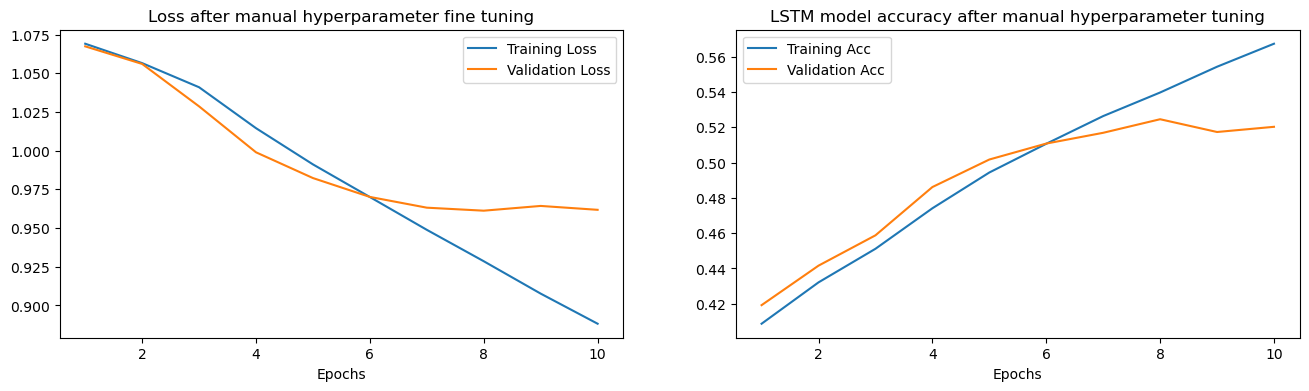

In [559]:
# Plotting the loss on the first subplot
hist_m = model_LSTM_manual_fit.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), hist_m['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist_m['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss after manual hyperparameter fine tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), hist_m['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs+1), hist_m['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('LSTM model accuracy after manual hyperparameter tuning')
plt.show()

As we can see from above, we seem to be in a decent spot, and training it more would like cause more overfitting.

In [560]:
# Evaluating the model against X_test and Y_test
model_LSTM_manual.evaluate(X_test, Y_test)

149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4986 - loss: 0.9875


[0.9765779376029968, 0.5052631497383118]

On a more positive note, evaluating this model with the test dataset shows us that the forecasting does perform much better than before (previous accuracy was ~0.40 with the test dataset). This is likely the case because the training data we used was much closer to the test data, and we were able to take advantage of that time proximity to make our predictions.

With that being said, we should also be careful of these results BECAUSE our test data is comparatively much more limited (though 4,750 results is still likely enough data points).

### Plotting a confusion matrix for the test predictions

In [565]:
# Getting Y_test_pred for the model
Y_test_pred = model_LSTM_manual.predict(X_test)
Y_test_pred = np.argmax(Y_test_pred, axis = 1)

# Getting the confusion matrix using Y_test and Y_test_pred
cf = confusion_matrix(
    Y_test,
    Y_test_pred
)

print('Generating the confusion matrix using confusion_matrix from '
  'sklearn.metrics:')
cf

149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
Generating the confusion matrix using confusion_matrix from sklearn.metrics:


array([[921, 315, 403],
       [474, 563, 450],
       [396, 312, 916]])

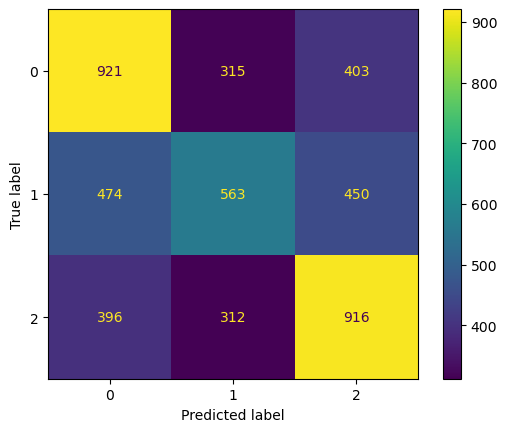

In [568]:
# Plotting the confusion matrix for the model (getting vertical xticks)
disp = ConfusionMatrixDisplay.from_predictions(
    y_true=Y_test,
    y_pred=Y_test_pred,
    labels=None
)

In [572]:
# Getting the precision and recall scores:
precision = sklearn.metrics.precision_score(Y_test, Y_test_pred, average=None)
recall = sklearn.metrics.recall_score(Y_test, Y_test_pred, average=None)

print("Determining precision for each class:")
print(precision, '\n')
print("Determining recall for each class:")
print(recall, '\n')
print("With 2 being positive prediction, 0 being negative, and 1 being neutral.")

Determining precision for each class:
[0.51423786 0.47310924 0.51780667] 

Determining recall for each class:
[0.561928   0.37861466 0.56403941] 

With 2 being positive prediction, 0 being negative, and 1 being neutral.


What matters for us is precision (TP / (TP + FP)), as we care about how "right" we are when we predict a certain class. For example, if we predict a stock to close higher than its open for a particular day, we want to know how "precise" that measurement is. In our case, the precision for the long-entry case (positive - 2) and the short-entry case (negative - 0) were both around 51%, which doesn't show much promise. However, we do need to keep in mind that because we're considering 3 classes, 51% might not be so bad.

More specifically, we might be able to exclude the "neutral" class of 1 when considering our precision, as this neutral case just means that the stock didn't move very much. For a more concrete example, imagine that the Open price of a stock is 100 USD. Our definition of a "neutral" class is that the stock price remains between 0.5% and -0.5% of its opening price, which in our case would mean between 99.5 USD and 100.5 USD. Thus, if we went long and **bought** 10 shares of this stock (for a total cost of $1000), our maximum gain or loss would be ±5 USD (disregarding any fees or commissions that need to be paid).

Based on the matrix above, if our model predicted that we should've entered long, we would've remained neutral about 25% of the time (450 / (403 + 450 + 916)). However, that also means that 52% of the time (916 / (403 + 450 + 916)) we would've made money, and 22% of the time (403 / (403 + 450 + 916)) we would've lost money. In essence, here's what our numbers would look like if we exclude the neutral case:
 - Precision for class 0: **70%** (921 / (921 + 396))
 - Precision for class 2: **69%** (916 / (403 + 916))

While this of course does not guarantee profitability, it does provide some evidence that the model is performing better than before.

## LSTM Classification (all stocks, longer series, smaller test and validation data sizes)

### Generating X continuous series sequences, Y continuous labels, and splitting data into train and test sets

In [578]:
# Creating sequences for LSTM model
seq_length = 35
group_col = 'Ticker'
target_col = 'Close_Open_Diff_Ternary'
drop_cols = ['Date_col', 'Close_Open_Diff_Perc']

X_data_smaller, Y_data_smaller = create_sequences_grouped(data_smaller, seq_length, group_col, target_col, drop_cols)

In [579]:
# Confirming shapes
print('Shape of X_data_smaller:', X_data_smaller.shape)
print('Shape of Y_data_smaller:', Y_data_smaller.shape, '\n')

# Confirming that we should have the correct number of sequences in X_data_smaller
unique_tickers = data_smaller['Ticker'].nunique()
unique_dates = data_smaller['Date_col'].nunique()
expected_num_sequences = unique_tickers * (unique_dates - seq_length + 1)

print('Number of unique tickers in data_smaller:', unique_tickers)
print('Number of unique dates in data_smaller:', unique_dates)
print('Chosen sequence length:', seq_length)
print('Number of sequences assuming the above seq_length:', unique_dates - seq_length + 1)
print('(We need to add 1 to the end to account for either the beginning or the end. For example, if we had 12 observations with a window')
print('of 5, we would need 12 - 5 + 1 = 8 sequences, the first one being having indices from [0:5], and the last from [7:12].)\n')
print('Total number of data sequences expected:', expected_num_sequences)
print('Total number of data sequences achieved:', X_data_smaller.shape[0])

Shape of X_data_smaller: (437475, 35, 32)
Shape of Y_data_smaller: (437475,) 

Number of unique tickers in data_smaller: 475
Number of unique dates in data_smaller: 955
Chosen sequence length: 35
Number of sequences assuming the above seq_length: 921
(We need to add 1 to the end to account for either the beginning or the end. For example, if we had 12 observations with a window
of 5, we would need 12 - 5 + 1 = 8 sequences, the first one being having indices from [0:5], and the last from [7:12].)

Total number of data sequences expected: 437475
Total number of data sequences achieved: 437475


In [580]:
# Getting the number of sequences per ticker (same calculation as above, but now defined in a variable)
num_sequences_per_ticker = unique_dates - seq_length + 1

# Splitting the data into train and test sets
num_train_seq_int = int(0.99 * num_sequences_per_ticker)  # Need int split to separate correct number of sequences for train and test data
train_size = num_train_seq_int * unique_tickers  # Another way to think about it: regardless of the num_train_seq_int value, we need to go
# ^up by the number of tickers (e.g., 400) at an integer amount each time
X_train = X_data_smaller[:train_size]
Y_train = Y_data_smaller[:train_size]
X_test = X_data_smaller[train_size:]
Y_test = Y_data_smaller[train_size:]

# Confirming shapes
print('Shape of X_train:', X_train.shape)
print('Shape of Y_train:', Y_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of Y_test:', Y_test.shape, '\n')

# Confirming number of dates
print('Number of dates in X_train:', num_train_seq_int)
print('Number of dates in X_test:', num_sequences_per_ticker - num_train_seq_int)

Shape of X_train: (432725, 35, 32)
Shape of Y_train: (432725,)
Shape of X_test: (4750, 35, 32)
Shape of Y_test: (4750,) 

Number of dates in X_train: 911
Number of dates in X_test: 10


### Building and compiling LSTM model

In [581]:
# Defining a function to create and compile tf model (256 LSTM units with longer series)
def build_LSTM_model_long(seq_length,
                     num_features,
                     n_classes,
                     hidden_layer_sizes=[],
                     learning_rate=0.01,
                     activation='relu',
                     optimizer='SGD',
                     metric='accuracy'):

    # Resetting tf for consistent results
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)
    
    # Building a model using tf Sequential
    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.Input(shape=(seq_length, num_features), name='Input'))
    
    # LSTM layer 1, dropout layer 1, LSTM layer 2, dropout layer 2
    model.add(LSTM(units=256, return_sequences=True, name='LSTM_1'))
    model.add(Dropout(0.2, name='Dropout_1'))
    model.add(LSTM(units=256, name='LSTM_2'))
    model.add(Dropout(0.2, name='Dropout_2'))

    # Output layer
    model.add(tf.keras.layers.Dense(
      units = n_classes,
      activation = 'softmax',
      name = 'Output'
    ))

    # Hidden layers
    for idx, hidden_layer_size in enumerate(hidden_layer_sizes):
      model.add(tf.keras.layers.Dense(
          units = hidden_layer_size,
          activation = 'relu',
          name = 'Hidden'+str(idx)
      ))
    
    # Setting optimizer and specific learning rate
    optimizer_class = getattr(tf.keras.optimizers, optimizer)
    optimizer_true = optimizer_class(learning_rate=learning_rate)
    
    # Compiling the model
    model.compile(
      optimizer = optimizer_true,
      loss = tf.keras.losses.SparseCategoricalCrossentropy(),
      metrics = [metric]
    )
    
    return model

### Hyperparameter-tuned LSTM model

In [585]:
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
seq_length = X_train.shape[1]
num_features = X_train.shape[2]
n_classes = 3
hidden_layer_sizes = []
learning_rate = 0.001
activation = 'relu'
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 1024

# Building and compiling the model
model_LSTM_long = build_LSTM_model_long(seq_length=seq_length,
                                      num_features=num_features,
                                      n_classes=n_classes,
                                      hidden_layer_sizes=hidden_layer_sizes,
                                      learning_rate=learning_rate,
                                      activation=activation,
                                      optimizer=optimizer,
                                      metric=metric)
print(model_LSTM_long.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_1 (LSTM)                   │ (None, 35, 256)        │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 35, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,019 (3.14 MB)

 Trainable params: 822,019 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

None


In [586]:
# Training the model using the training dataset
model_LSTM_long_fit = model_LSTM_long.fit(
    x = X_train,
    y = Y_train,
    validation_split = 0.01,  # Validation split also 0.01 just like the test split
    epochs = num_epochs,
    batch_size = batch_size,
    verbose = 1
)

Epoch 1/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 265s 631ms/step - accuracy: 0.3831 - loss: 1.0852 - val_accuracy: 0.4104 - val_loss: 1.0733
Epoch 2/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 268s 639ms/step - accuracy: 0.4130 - loss: 1.0665 - val_accuracy: 0.4281 - val_loss: 1.0620
Epoch 3/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 259s 618ms/step - accuracy: 0.4294 - loss: 1.0583 - val_accuracy: 0.4420 - val_loss: 1.0526
Epoch 4/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 260s 621ms/step - accuracy: 0.4434 - loss: 1.0492 - val_accuracy: 0.4545 - val_loss: 1.0404
Epoch 5/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 267s 638ms/step - accuracy: 0.4622 - loss: 1.0308 - val_accuracy: 0.4764 - val_loss: 1.0154
Epoch 6/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 262s 624ms/step - accuracy: 0.4844 - loss: 1.0045 - val_accuracy: 0.4889 - val_loss: 0.9866
Epoch 7/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 268s 640ms/step - accuracy: 0.5056 - loss: 0.9786 - val_accuracy: 0.5035 - val_loss: 0.9660
Epoch 8/10
419/419 ━━━━━━━━━━━━━━━━━━━━ 269s 643ms/step - accuracy: 0.5232 -

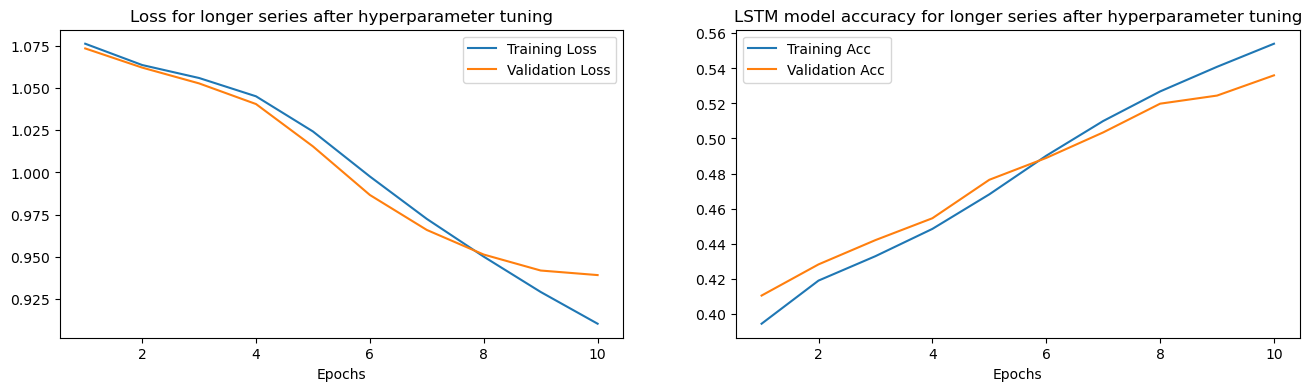

In [587]:
# Plotting the loss on the first subplot
hist_l = model_LSTM_long_fit.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), hist_l['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist_l['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss for longer series after hyperparameter tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), hist_l['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs+1), hist_l['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('LSTM model accuracy for longer series after hyperparameter tuning')
plt.show()

As it takes over 4 minutes to run each epoch, and the validation loss seems to be plateauing now, it probably doesn't make sense to waste more compute and continue running. However, even with this run, we see that the validation accuracy almost reaches 54%, which is an improvement over the previous model with a smaller window of 14 days.

In [588]:
print("Final training accuracy:", hist_l['accuracy'][-1])
print("Final validation accuracy:", hist_l['val_accuracy'][-1])

Final training accuracy: 0.554088830947876
Final validation accuracy: 0.5360443592071533


In [589]:
# Evaluating the model against X_test and Y_test
model_LSTM_long.evaluate(X_test, Y_test)

149/149 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.5347 - loss: 0.9519


[0.9456785321235657, 0.5343157649040222]

Once again, evaluating this longer-sequence model with the test dataset shows us that the forecasting does perform much better than before (previous accuracy was ~0.40 with the longer sequences). Again, this is likely the case because the training data we used was much closer to the test data, and we were able to take advantage of that time proximity to make our predictions.

Also again, we should be careful of these results because our test data is comparatively much more limited (though 4,750 results is still likely enough data points). But it's good to see that the training, validation, and test accuracies were even better than the previous model with shorter sequences.

### Plotting a confusion matrix for the test predictions

In [590]:
# Getting Y_test_pred for the model
Y_test_pred = model_LSTM_long.predict(X_test)
Y_test_pred = np.argmax(Y_test_pred, axis = 1)

# Getting the confusion matrix using Y_test and Y_test_pred
cf = confusion_matrix(
    Y_test,
    Y_test_pred
)

print('Generating the confusion matrix using confusion_matrix from '
  'sklearn.metrics:')
cf

149/149 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step
Generating the confusion matrix using confusion_matrix from sklearn.metrics:


array([[979, 346, 327],
       [413, 623, 451],
       [348, 327, 936]])

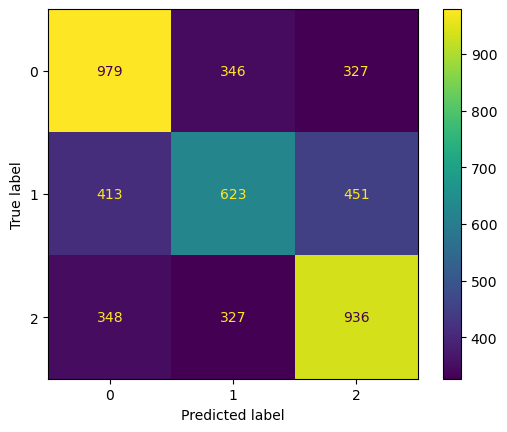

In [591]:
# Plotting the confusion matrix for the model (getting vertical xticks)
disp = ConfusionMatrixDisplay.from_predictions(
    y_true=Y_test,
    y_pred=Y_test_pred,
    labels=None
)

In [592]:
# Getting the precision and recall scores:
precision = sklearn.metrics.precision_score(Y_test, Y_test_pred, average=None)
recall = sklearn.metrics.recall_score(Y_test, Y_test_pred, average=None)

print("Determining precision for each class:")
print(precision, '\n')
print("Determining recall for each class:")
print(recall, '\n')
print("With 2 being positive prediction, 0 being negative, and 1 being neutral.")

Determining precision for each class:
[0.56264368 0.48070988 0.54609102] 

Determining recall for each class:
[0.59261501 0.41896436 0.58100559] 

With 2 being positive prediction, 0 being negative, and 1 being neutral.


Once again, what matters for us is precision (TP / (TP + FP)), as we care about how "right" we are when we predict a certain class. For example, if we predict a stock to close higher than its open for a particular day, we want to know how "precise" that measurement is. Similar to the case above, when considering precision of only classes 2 and 0, we get the following precision values:
 - Precision for class 0: **74%** (979 / (979 + 348))
 - Precision for class 2: **74%** (936 / (327 + 936))

Overall, our precision was even more accurate the the previous model, and we notice that we're almost 3 times more likely as we are to make money rather than lose money. Once again, while this of course does not guarantee profitability (especially since we're not considering the neutral case), it provides more evidence that the model is performing better than before.

### (Optional) One more test with hyperparameter tuning (256 batch size instead of 1024, and 15 epochs instead of 10)

In [593]:
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
seq_length = X_train.shape[1]
num_features = X_train.shape[2]
n_classes = 3
hidden_layer_sizes = []
learning_rate = 0.001
activation = 'relu'
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 15
batch_size = 256

# Building and compiling the model
model_LSTM_long = build_LSTM_model_long(seq_length=seq_length,
                                      num_features=num_features,
                                      n_classes=n_classes,
                                      hidden_layer_sizes=hidden_layer_sizes,
                                      learning_rate=learning_rate,
                                      activation=activation,
                                      optimizer=optimizer,
                                      metric=metric)
print(model_LSTM_long.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_1 (LSTM)                   │ (None, 35, 256)        │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 35, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,019 (3.14 MB)

 Trainable params: 822,019 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

None


In [594]:
# Training the model using the training dataset
model_LSTM_long_fit = model_LSTM_long.fit(
    x = X_train,
    y = Y_train,
    validation_split = 0.01,  # Validation split also 0.01 just like the test split
    epochs = num_epochs,
    batch_size = batch_size,
    verbose = 1
)

Epoch 1/15
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 342s 204ms/step - accuracy: 0.3914 - loss: 1.0796 - val_accuracy: 0.4279 - val_loss: 1.0642
Epoch 2/15
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 340s 203ms/step - accuracy: 0.4268 - loss: 1.0595 - val_accuracy: 0.4385 - val_loss: 1.0555
Epoch 3/15
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 331s 198ms/step - accuracy: 0.4442 - loss: 1.0482 - val_accuracy: 0.4665 - val_loss: 1.0256
Epoch 4/15
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 330s 197ms/step - accuracy: 0.4749 - loss: 1.0143 - val_accuracy: 0.4908 - val_loss: 0.9909
Epoch 5/15
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 332s 198ms/step - accuracy: 0.5026 - loss: 0.9790 - val_accuracy: 0.5076 - val_loss: 0.9729
Epoch 6/15
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 333s 199ms/step - accuracy: 0.5240 - loss: 0.9517 - val_accuracy: 0.5199 - val_loss: 0.9513
Epoch 7/15
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 344s 205ms/step - accuracy: 0.5412 - loss: 0.9271 - val_accuracy: 0.5319 - val_loss: 0.9421
Epoch 8/15
1674/1674 ━━━━━━━━━━━━━━━━━━━━ 339s 202ms/step - ac

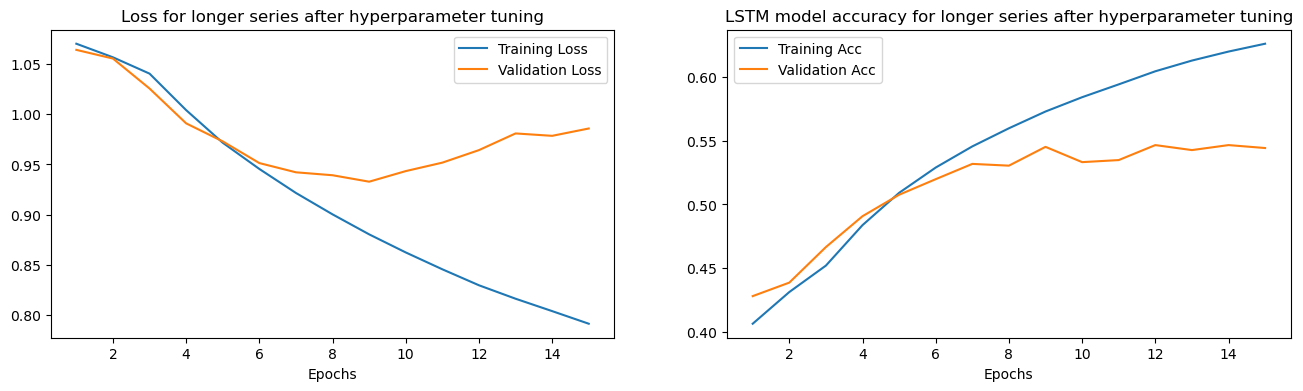

In [595]:
# Plotting the loss on the first subplot
hist_l = model_LSTM_long_fit.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), hist_l['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist_l['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss for longer series after hyperparameter tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), hist_l['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs+1), hist_l['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('LSTM model accuracy for longer series after hyperparameter tuning')
plt.show()

It took over 6 minutes to run each epoch, and overall the validation loss hasn't improved that much (and it started overfitting). Thus, it probably makes sense to just keep the previous model and not worry too much about it.

# Pause to Explain Why Series Data Needs Correction

Quick note about everything done above: all the models ran above were based on an initial dataset that had a very specific type of normalization/standardization. Specifically, all the price data were normalized to the Open price of that particular day, and all the volume data were normalized to the Previous Day Volume (PDV). This is why those values are equal to 1 when we describe the dataset below:

In [602]:
data_small.describe()

,Date_col,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Daily_Range_Gap_Up,Daily_Range_Gap_Down,Avg_Vol_Prev_14D,Vol_Change,SMA_prev_14,SMA_prev_50,EMA_prev_9,EMA_prev_20,RSI_prev_14,NATR_14,Close_Open_Diff_Perc,Close_Open_Diff_Ternary
count,453625,453625.0,453625.000000,453625.000000,453625.000000,453625.000000,453625.0,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000
mean,2023-02-06 10:24:15.078534144,1.0,1.000002,1.011605,0.988031,0.999817,1.0,0.030902,0.101300,-0.098990,1.127009,0.023919,0.999526,0.997305,0.999650,0.999368,0.517830,2.362572,0.008622,1.011241
min,2021-03-17 00:00:00,1.0,0.551247,0.718593,0.505540,0.650754,1.0,-38.803893,0.000000,-38.638898,0.106901,-0.915551,0.319846,0.205900,0.414858,0.318473,0.032035,0.212823,-50.071084,0.000000
25%,2022-02-24 00:00:00,1.0,0.989812,1.002464,0.981860,0.995384,1.0,-0.383452,0.000000,0.000000,0.869907,-0.263134,0.975567,0.948123,0.983793,0.973826,0.430360,1.748904,-0.845422,0.000000
50%,2023-02-07 00:00:00,1.0,0.999342,1.008763,0.989958,0.999589,1.0,0.041106,0.000000,0.000000,1.082361,-0.083369,0.996294,0.989568,0.997516,0.995584,0.517854,2.163510,0.025686,1.000000
75%,2024-01-22 00:00:00,1.0,1.009401,1.017522,0.996182,1.003849,1.0,0.463727,0.000000,0.000000,1.327669,0.161837,1.019872,1.037169,1.013151,1.020416,0.605545,2.738881,0.871954,2.000000
max,2024-12-31 00:00:00,1.0,1.684394,1.705303,1.629697,1.634091,1.0,53.667959,39.160845,0.000000,9.746261,25.587868,1.826748,2.091983,1.744173,3.551677,0.963161,18.195811,32.653064,2.000000
std,NaN,0.0,0.019863,0.016485,0.015383,0.011379,0.0,1.112548,0.484430,0.532302,0.398665,0.534852,0.041281,0.077294,0.028310,0.043858,0.121727,0.911041,1.619073,0.828860


(*We note that some of the percentage changes, the SMAs/EMAs, and the RSI/NATR values are fine as is, since they're just scaled up or down by 100%)

The main issue is now the interpretation of this data. If we stick with the price data (Open PDO, PDH, etc.), what we essentially did was have the Open price of every single day be the **exact same**. In other words, we've normalized **every** single price feature to the price of 1.0. The main implication of this is that we lose the movement of stock prices. While we can still see large movements and gaps up or down (because we have the previous day values as our features), any **sequential** movement across each series is lost. This means that we don't really get to see much price action movement over the long term.

To fix this, we need to restructure our dataset so that any features that require sequential movement are updated appropriately. In other words, we need global normalization (e.g., MinMax) across all dates, for every ticker (as we still want to keep the ticker prices separated and normalized). This will ultimately preserve price trends, and our model will hopefully be able to learn better.

With that being said, not all is lost, and we can still find some interpretation from this data. Specifically, even without long-term temporal dependencies, our most recent model still achieved an accuracy of ~74% (when we excluded the neutral case). This might imply that the previous day features are the most indicative when it comes to predicting the Close price, or that other metrics (i.e., SMAs, RSI, NATR) play a larger role that we anticipated.

Overall, after we create the new dataset and re-run our models on that data, **the difference in accuracy between those models and these ones should, in theory, reflect the extent to which long-term temporal dependencies influence the model's ability to predict stock price movements**. This is primarily because we will maintain the relative differences between the different price (and volume) features - along with using the same model architecture - and the only change will be how prices are scaled relative to each individual day.

We will accomplish this in the next set of notebooks.